# Demo 3: Imbalanced Classification & Model Interpretation (Disease Prediction)

This demo addresses a common challenge in health data: **imbalanced classes**. Often, the condition we want to predict (e.g., a rare disease) is much less frequent than the negative case. Standard models trained on imbalanced data tend to perform poorly on the minority class because they can achieve high accuracy simply by predicting the majority class most of the time.

We will:

1. Generate synthetic imbalanced data mimicking a rare disease prediction task, including a categorical feature.
2. Handle the categorical feature using `OneHotEncoder`.
3. Apply **SMOTE** (Synthetic Minority Over-sampling Technique) to balance the *training* data.
4. Train a classifier (RandomForest) on the balanced training data.
5. Evaluate the model, focusing on metrics sensitive to imbalance (Recall, F1-score, AUC).
6. Use **eli5** to interpret the model's feature importances.

## 0. Setup: Install Required Packages 📦

In [1]:
%pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


## 1. Setup: Import Libraries

We import necessary libraries:

- Standard data science tools: `numpy`, `pandas`, `matplotlib`, `seaborn`.
- `sklearn.datasets`: To generate synthetic data.
- `sklearn.model_selection`: For splitting data.
- `sklearn.preprocessing`: For `OneHotEncoder`.
- `sklearn.ensemble`: For `RandomForestClassifier`.
- `sklearn.metrics`: For evaluation, including `roc_curve`.
- `imblearn.over_sampling`: For `SMOTE` (install via `pip install imbalanced-learn`).
- `eli5`: For model interpretation (install via `pip install eli5`).
Setting the random seed ensures reproducibility.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve # Added roc_curve
from imblearn.over_sampling import SMOTE # Needs: pip install imbalanced-learn
import eli5 # Needs: pip install eli5

# Configure plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('pastel')
np.random.seed(42) # for reproducibility
import warnings
warnings.filterwarnings('ignore', category=FutureWarning) # Ignore future warnings from eli5/sklearn

## 2. Generate Synthetic Imbalanced Data with Categorical Feature

We use `make_classification` again, but this time create a highly imbalanced dataset (`weights=[0.95, 0.05]`) representing a rare condition (5% positive cases). We also add a synthetic categorical feature ('Region') to demonstrate encoding.

'Dataset Shape:'

(2000, 12)

'\nClass distribution (RareDisease):'

RareDisease
0    1892
1     108
Name: count, dtype: int64

RareDisease
0    0.946
1    0.054
Name: count, dtype: float64

'\nCategorical feature distribution (Region):'

Region
North    615
East     512
West     501
South    372
Name: count, dtype: int64

'\nFirst 5 rows:'

,cont_feat_1,cont_feat_2,cont_feat_3,cont_feat_4,cont_feat_5,cont_feat_6,cont_feat_7,cont_feat_8,cont_feat_9,cont_feat_10,Region,RareDisease
0,1.719421,-0.995037,1.347159,-0.105095,2.238050,0.120165,0.630093,0.341180,0.365803,-1.431276,South,0
1,1.628344,-0.526241,0.116202,1.399840,1.955209,0.610469,-0.102266,1.759813,0.484695,-1.058643,West,0
2,0.855182,1.525454,1.932957,-2.284388,-1.581202,1.583316,0.696688,-0.174947,-0.090593,0.141984,East,0
3,-0.007153,-0.589655,0.092564,0.956371,-1.073790,-0.219023,0.434362,-1.748067,-1.201759,1.585682,East,0
4,0.713820,-0.559466,-0.411422,-0.700216,2.681279,0.096479,0.373257,-0.193602,0.746925,-2.103692,North,0


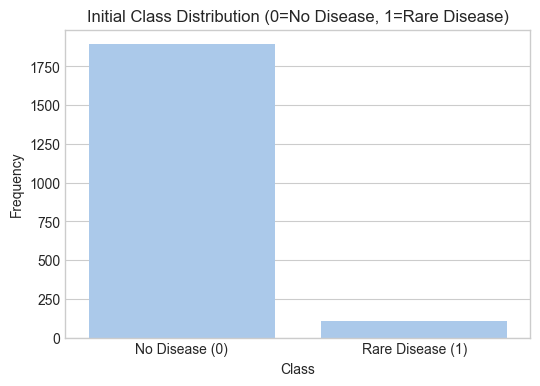

In [3]:
# Generate imbalanced data
X, y = make_classification(
    n_samples=2000,
    n_features=10,       # More features
    n_informative=5,     # Only 5 features are actually useful
    n_redundant=2,
    n_clusters_per_class=2, # Make classes slightly harder to separate
    weights=[0.95, 0.05], # Highly imbalanced: 95% class 0, 5% class 1 (rare disease)
    flip_y=0.01,         # Low noise
    random_state=42
)

# Create DataFrame
feature_names = [f'cont_feat_{i+1}' for i in range(10)]
df = pd.DataFrame(X, columns=feature_names)

# Add a synthetic categorical feature
regions = ['North', 'South', 'East', 'West']
df['Region'] = np.random.choice(regions, size=df.shape[0], p=[0.3, 0.2, 0.25, 0.25])

df['RareDisease'] = y # Target variable

display("Dataset Shape:", df.shape)
display("\nClass distribution (RareDisease):")
target_counts = df['RareDisease'].value_counts()
display(target_counts)
display(target_counts / len(df)) # Print proportions
display("\nCategorical feature distribution (Region):")
display(df['Region'].value_counts())
display("\nFirst 5 rows:")
display(df.head())

# Visualize the imbalance using counts
plt.figure(figsize=(6, 4))
sns.countplot(x='RareDisease', data=df)
plt.title('Initial Class Distribution (0=No Disease, 1=Rare Disease)')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.xticks([0, 1], ['No Disease (0)', 'Rare Disease (1)'])
plt.show()

## 3. Split Data into Training and Testing Sets

**Crucially**, we split the data *before* applying any preprocessing (encoding or SMOTE). This prevents "data leakage," where information from the test set inadvertently influences the training process. The test set must remain completely unseen until final evaluation. We use `stratify=y` so both splits keep similar class proportions.

In [4]:
# Separate features (X) and target (y)
X = df.drop('RareDisease', axis=1)
y = df['RareDisease']

# Split FIRST (before encoding or SMOTE)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Essential for imbalanced data!
)

display("Training set shape:", X_train_raw.shape)
display("Testing set shape:", X_test_raw.shape)
display("\nTraining set class distribution:")
display(y_train.value_counts(normalize=True))
display("\nTesting set class distribution:")
display(y_test.value_counts(normalize=True))

'Training set shape:'

(1600, 11)

'Testing set shape:'

(400, 11)

'\nTraining set class distribution:'

RareDisease
0    0.94625
1    0.05375
Name: proportion, dtype: float64

'\nTesting set class distribution:'

RareDisease
0    0.945
1    0.055
Name: proportion, dtype: float64

## 4. Preprocessing: One-Hot Encode Categorical Feature (Fit on Train Only)

Machine learning models need numerical input. We convert the 'Region' column using `OneHotEncoder`. **Fit the encoder only on the training data**, then transform both train and test. That way the model never sees test-set categories during training.

In [5]:
# Identify categorical and numerical columns
categorical_cols = ['Region']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Initialize OneHotEncoder and fit on TRAINING data only
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train_raw[categorical_cols])

encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

# Transform both train and test using the same fitted encoder
X_train_encoded = encoder.transform(X_train_raw[categorical_cols])
X_test_encoded = encoder.transform(X_test_raw[categorical_cols])

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_feature_names, index=X_train_raw.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_feature_names, index=X_test_raw.index)

# Combine numerical and encoded categorical features
X_train_processed = pd.concat([X_train_raw[numerical_cols].reset_index(drop=True), X_train_encoded_df.reset_index(drop=True)], axis=1)
X_test_processed = pd.concat([X_test_raw[numerical_cols].reset_index(drop=True), X_test_encoded_df.reset_index(drop=True)], axis=1)

# Store final feature names for eli5 later
final_feature_names = list(X_train_processed.columns)

display("Processed training shape:", X_train_processed.shape)
display("Processed testing shape:", X_test_processed.shape)
display("\nFirst 5 rows of processed training data:")
display(X_train_processed.head())

'Processed training shape:'

(1600, 14)

'Processed testing shape:'

(400, 14)

'\nFirst 5 rows of processed training data:'

,cont_feat_1,cont_feat_2,cont_feat_3,cont_feat_4,cont_feat_5,cont_feat_6,cont_feat_7,cont_feat_8,cont_feat_9,cont_feat_10,Region_East,Region_North,Region_South,Region_West
0,0.178114,2.125257,1.065103,-0.086620,1.600675,1.886337,0.605098,0.589337,2.143832,-2.505288,0.0,1.0,0.0,0.0
1,0.770526,3.621944,-1.150169,-2.252871,-3.929142,3.790216,-2.931097,-0.627878,-0.708686,1.439127,0.0,1.0,0.0,0.0
2,-1.812159,1.679275,-1.598313,-0.035838,3.011683,1.427516,-0.171974,0.987075,1.662553,-3.036378,0.0,1.0,0.0,0.0
3,1.761655,1.719651,-0.172551,-0.491641,0.726293,1.704591,1.456789,0.059853,2.045100,-1.934845,0.0,1.0,0.0,0.0
4,-1.054934,2.124466,-1.647887,0.530946,0.500863,0.677297,-0.545659,-0.221752,2.437623,-1.753808,1.0,0.0,0.0,0.0


## 5. Handle Imbalance with SMOTE (on Training Data Only!)

Now we address the class imbalance using SMOTE. SMOTE synthetically creates new examples of the minority class (RareDisease=1) by interpolating between existing minority class samples.
**Crucially, SMOTE is applied *only* to the processed training data (`X_train_processed`, `y_train`).** Applying it to the test data would artificially inflate performance metrics because the model would be evaluated on synthetic data it helped create.

First, let's visualize the original training data distribution using two features to see the imbalance.

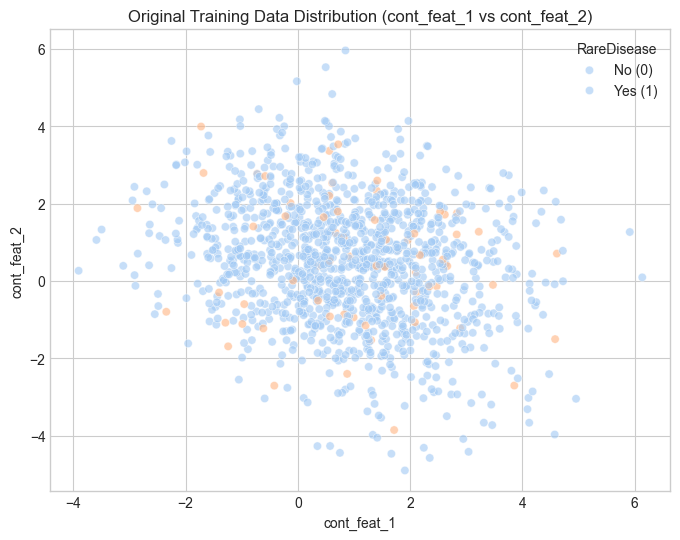

'\nOriginal training distribution (counts):'

RareDisease
0    1514
1      86
Name: count, dtype: int64

'\nApplying SMOTE to training data...'

'SMOTE application complete.'

'\nResampled training distribution (counts):'

RareDisease
0    1514
1    1514
Name: count, dtype: int64

'\nResampled training features shape:'

(3028, 14)

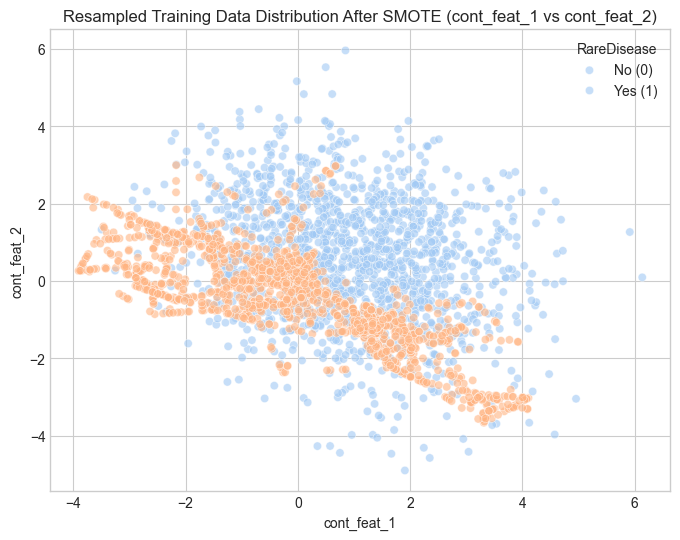

In [6]:
# Visualize original training data distribution (using first two continuous features)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_processed.iloc[:, 0], y=X_train_processed.iloc[:, 1], hue=y_train, alpha=0.6, palette='pastel')
plt.title(f'Original Training Data Distribution ({X_train_processed.columns[0]} vs {X_train_processed.columns[1]})')
plt.xlabel(X_train_processed.columns[0])
plt.ylabel(X_train_processed.columns[1])
plt.legend(title='RareDisease', labels=['No (0)', 'Yes (1)'])
plt.show()

display("\nOriginal training distribution (counts):")
display(y_train.value_counts())

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to the training data
display("\nApplying SMOTE to training data...")
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)
display("SMOTE application complete.")

display("\nResampled training distribution (counts):")
display(y_train_resampled.value_counts()) # Should be equal counts
display("\nResampled training features shape:", X_train_resampled.shape)

# Visualize the resampled training data distribution
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train_resampled.iloc[:, 0], y=X_train_resampled.iloc[:, 1], hue=y_train_resampled, alpha=0.6, palette='pastel')
plt.title(f'Resampled Training Data Distribution After SMOTE ({X_train_processed.columns[0]} vs {X_train_processed.columns[1]})')
plt.xlabel(X_train_processed.columns[0])
plt.ylabel(X_train_processed.columns[1])
plt.legend(title='RareDisease', labels=['No (0)', 'Yes (1)'])
plt.show()

## 6. Train a RandomForest Classifier

We train a RandomForestClassifier on the **resampled (balanced) training data**. This ensures the model learns from both classes adequately, rather than being biased towards the original majority class.

In [7]:
# Initialize RandomForest
rf_smote = RandomForestClassifier(n_estimators=150, random_state=42, class_weight='balanced', n_jobs=-1)
# Using class_weight='balanced' as an additional measure, though SMOTE is primary

# Train on the RESAMPLED training data
display("Training RandomForest on SMOTE-resampled data...")
rf_smote.fit(X_train_resampled, y_train_resampled)
display("Model training complete.")

'Training RandomForest on SMOTE-resampled data...'

'Model training complete.'

## 7. Evaluate the Model (on Original Test Set)

We evaluate the model trained on balanced data using the **original, processed test set** (`X_test_processed`, `y_test`). This reflects real-world performance on unseen, imbalanced data.

Pay close attention to:

- **Confusion Matrix:** How many actual rare disease cases (True Positives) did we catch? How many did we miss (False Negatives)?
- **Classification Report:** Specifically, look at the **Recall** for the minority class (RareDisease=1). High recall here means the model is good at identifying the rare cases, which is often the primary goal in imbalanced health problems. Also check the F1-score for a balance between precision and recall.
- **AUC & ROC Curve:** Provide threshold-independent measures of model separability.

'\n--- Evaluation on Original Test Set (Model trained on SMOTE data) ---'

'Accuracy: 0.9550'

'\nConfusion Matrix:'

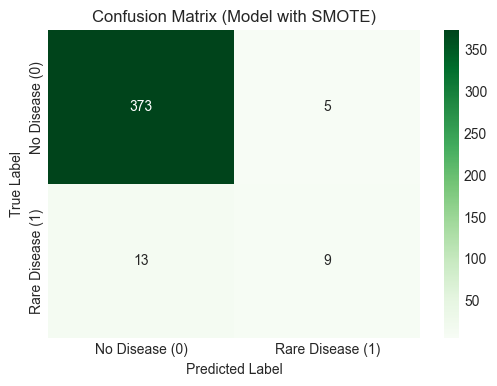

'\nClassification Report:'

'                  precision    recall  f1-score   support\n\n  No Disease (0)       0.97      0.99      0.98       378\nRare Disease (1)       0.64      0.41      0.50        22\n\n        accuracy                           0.95       400\n       macro avg       0.80      0.70      0.74       400\n    weighted avg       0.95      0.95      0.95       400\n'

'\nAUC: 0.8935'

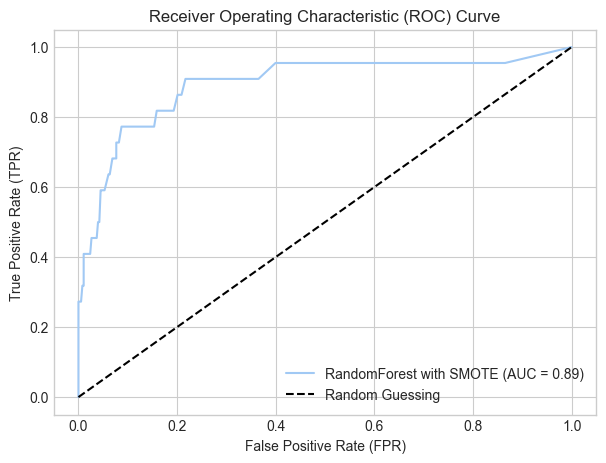

In [8]:
# Make predictions on the ORIGINAL (but processed) test set
y_pred_smote = rf_smote.predict(X_test_processed)
y_pred_proba_smote = rf_smote.predict_proba(X_test_processed)[:, 1] # Probabilities for AUC/ROC

# --- Evaluation ---
display("\n--- Evaluation on Original Test Set (Model trained on SMOTE data) ---")

# Accuracy
accuracy_smote = accuracy_score(y_test, y_pred_smote)
display(f"Accuracy: {accuracy_smote:.4f}") # Note: Accuracy might not be the best metric here!

# Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
display("\nConfusion Matrix:")
# display(cm_smote)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_smote, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Disease (0)', 'Rare Disease (1)'],
            yticklabels=['No Disease (0)', 'Rare Disease (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Model with SMOTE)')
plt.show()


# Classification Report - Focus on Recall for class 1!
report_smote = classification_report(y_test, y_pred_smote, target_names=['No Disease (0)', 'Rare Disease (1)'])
display("\nClassification Report:")
display(report_smote)

# AUC
auc_smote = roc_auc_score(y_test, y_pred_proba_smote)
display(f"\nAUC: {auc_smote:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_smote)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'RandomForest with SMOTE (AUC = {auc_smote:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing') # Diagonal line
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.grid(True)
plt.show()

## 8. Model Interpretation with eli5

eli5 helps explain the model's decisions. `eli5.explain_weights` displays the features ranked by their importance (using permutation importance or impurity-based importance for tree models). This helps identify which factors (original continuous features or encoded regions) the model found most predictive.

We pass the trained model (`rf_smote`) and the final feature names.

In [9]:
display("\n--- eli5 Feature Importances ---")

# Show feature importances calculated by eli5
# For RandomForest, eli5 typically uses feature impurity by default.
explanation = eli5.explain_weights(rf_smote, feature_names=final_feature_names, top=15)

# Format as HTML with custom styling for black text
from eli5.formatters import format_as_html
from IPython.display import HTML

html_explanation = format_as_html(explanation)
styled_html = f'<div style="color: black !important;">{html_explanation}</div>'
display("Displaying top 15 feature importances:")
display(HTML(styled_html))

'\n--- eli5 Feature Importances ---'

'Displaying top 15 feature importances:'

Weight,Feature
0.1579 ± 0.1404,cont_feat_1
0.1245 ± 0.1662,cont_feat_4
0.1068 ± 0.1406,cont_feat_6
0.1051 ± 0.1143,cont_feat_5
0.0901 ± 0.1128,cont_feat_2
0.0825 ± 0.0850,cont_feat_9
0.0805 ± 0.0922,cont_feat_10
0.0512 ± 0.0975,Region_West
0.0432 ± 0.1145,Region_North
0.0383 ± 0.0327,cont_feat_7


## 9. Interpretation & Conclusion

Let's analyze the results:

- **Impact of SMOTE:** Compare the recall for the 'Rare Disease (1)' class in the classification report to what you might expect without SMOTE (likely much lower). SMOTE significantly improves the model's ability to detect the minority class, even if overall accuracy doesn't change much (or even slightly decreases). The scatter plots visually demonstrate how SMOTE adds synthetic minority samples to balance the feature space representation in the training data.
- **Evaluation Metrics:** For imbalanced problems, focus on Recall (Sensitivity) for the minority class, F1-score, and AUC/ROC curve. High recall means fewer missed cases of the rare disease. The ROC curve visually confirms the model's ability to separate classes better than random guessing.
- **eli5 Interpretation:** The eli5 feature-weights output (from `show_weights` or `explain_weights`) reveals which features contributed most to the RandomForest's predictions. This could highlight key continuous variables or even indicate if certain regions (from the one-hot encoded features) were associated with the rare disease in our synthetic data. Understanding feature importance is vital for validating if the model is learning meaningful patterns or relying on artifacts.

Applying SMOTE only on the training data prevents data leakage: if we applied it before splitting, synthetic samples could reflect test-set information and inflate reported performance; the test set should represent unseen, imbalanced data. Accuracy can be misleading when classes are imbalanced because a model can achieve high accuracy by always predicting the majority class; recall for the minority class, F1-score, and AUC/ROC are more informative. The eli5 feature-weights output ranks features by how much they contribute to predictions (e.g. impurity reduction across trees); if a feature like `Region_East` appears high, it was a relatively strong predictor of the outcome in this synthetic data.